# Option-Implied Skew, Volatility, and Risk-Regime Filters

This notebook tests whether ex-ante FX option signals and global risk-regime variables can improve FX carry. The goal is not to optimize parameters, but to see whether option-implied volatility, risk reversals, butterflies, and broad risk-off regimes help identify bad carry before losses occur.

The notebook uses existing downloaded and processed files only. It does not refetch Bloomberg data.


## Signal Conventions

Risk reversals require careful pair-direction handling. The notebook stores both raw and foreign-currency-adjusted risk reversals. The convention used for carry filtering is:

$$
\text{RR}^{\text{foreign}}_{i,t}
=
\sigma(\text{foreign call})_{i,t}
-
\sigma(\text{foreign put})_{i,t}
$$

Bad downside skew is defined as:

$$
\text{bad skew}_{i,t}
=
-
\text{RR}^{\text{foreign}}_{i,t}
$$

So a higher bad-skew value means foreign-currency downside protection is more expensive.

The option-adjusted carry score used in sensitivity tests is:

$$
\text{score}_{i,t}
=
z(\text{carry}_{i,t})
-
\lambda z(\text{ATM vol}_{i,t})
-
\gamma z(\text{bad skew}_{i,t})
$$

Monthly roll costs are computed as:

$$
\text{roll cost}_t
=
\text{gross roll notional}_t
\times
\frac{\text{bps}}{10000}
$$

where:

$$
\text{gross roll notional}_t
=
\sum_i |w_{i,t}|
$$

De-risking-only option-vol scaling uses:

$$
\ell_t
=
\min
\left(
1,
\frac{\sigma_{\text{target}}}{\hat{\sigma}^{\text{option}}_t}
\right)
$$

and:

$$
r^{\text{scaled}}_{t+1}
=
\ell_t r_{t+1}
$$


In [1]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "data").exists() and (candidate / "theo" / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root.")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "theo" / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

G10_PANEL_PATH = PROCESSED_DIR / "g10_1m_carry_panel.parquet"
EM_PANEL_PATH = PROCESSED_DIR / "em_1m_carry_panel.parquet"
G10_OPTIONS_PATH = RAW_DIR / "g10_fx_options_long.parquet"
EM_OPTIONS_PATH = RAW_DIR / "em_fx_options_long.parquet"
GLOBAL_RISK_PATH = RAW_DIR / "global_risk_long.parquet"

OPTION_PANEL_OUT = PROCESSED_DIR / "fx_option_signal_panel.parquet"
FILTERED_RETURNS_OUT = PROCESSED_DIR / "option_filtered_carry_returns.parquet"
FILTER_PERF_OUT = PROCESSED_DIR / "option_filter_performance.parquet"
CRISIS_ATTRIB_OUT = PROCESSED_DIR / "option_filter_crisis_attribution.parquet"

MONTHS_PER_YEAR = 12
ROLL_COST_BPS = [2, 5, 10, 25, 50]
OPTION_TYPES = ["V", "25R", "25B", "10R", "10B"]
OPTION_TENOR = "1M"

print(f"Project root: {ROOT}")


Project root: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo


## Load Carry, Option, and Global Risk Data

Missing files are reported clearly. Sections that require unavailable data will return empty diagnostics rather than crashing.


In [2]:
def safe_read_parquet(path):
    if not path.exists():
        return pd.DataFrame(), {"path": str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path), "loaded": False, "rows": 0, "message": "missing"}
    try:
        df = pd.read_parquet(path)
        return df, {"path": str(path.relative_to(ROOT)), "loaded": True, "rows": len(df), "message": ""}
    except Exception as exc:
        return pd.DataFrame(), {"path": str(path), "loaded": False, "rows": 0, "message": repr(exc)}

g10_carry_raw, st_g10 = safe_read_parquet(G10_PANEL_PATH)
em_carry_raw, st_em = safe_read_parquet(EM_PANEL_PATH)
g10_opts_raw, st_g10o = safe_read_parquet(G10_OPTIONS_PATH)
em_opts_raw, st_emo = safe_read_parquet(EM_OPTIONS_PATH)
global_risk_raw, st_risk = safe_read_parquet(GLOBAL_RISK_PATH)

display(pd.DataFrame([st_g10, st_em, st_g10o, st_emo, st_risk]))


,path,loaded,rows,message
0,theo/data/processed/g10_1m_carry_panel.parquet,True,2106,
1,theo/data/processed/em_1m_carry_panel.parquet,True,4169,
2,data/raw/g10_fx_options_long.parquet,True,4170477,
3,data/raw/em_fx_options_long.parquet,True,4847571,
4,data/raw/global_risk_long.parquet,True,95156,


In [3]:
def harmonize_g10(df):
    if df.empty:
        return pd.DataFrame()
    out = df.copy()
    out["month_end"] = pd.to_datetime(out["month_end"], errors="coerce")
    out["asset_class"] = "G10"
    if {"spot_usd_per_ccy", "forward_1m_usd_per_ccy", "next_month_spot_usd_per_ccy"}.issubset(out.columns):
        out["carry_signal_1m"] = np.log(out["spot_usd_per_ccy"]) - np.log(out["forward_1m_usd_per_ccy"])
        out["realized_1m_forward_excess_return"] = np.log(out["next_month_spot_usd_per_ccy"]) - np.log(out["forward_1m_usd_per_ccy"])
    return out[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return"]]

def harmonize_em(df):
    if df.empty:
        return pd.DataFrame()
    out = df.copy()
    out["month_end"] = pd.to_datetime(out["month_end"], errors="coerce")
    out["asset_class"] = "EM"
    return out[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return"]]

g10_carry = harmonize_g10(g10_carry_raw)
em_carry = harmonize_em(em_carry_raw)
carry_panel = pd.concat([g10_carry, em_carry], ignore_index=True).dropna(subset=["month_end", "currency"])

display(carry_panel.groupby("asset_class").agg(rows=("currency", "size"), currencies=("currency", "nunique"), first=("month_end", "min"), last=("month_end", "max")))


,rows,currencies,first,last
asset_class,,,,
EM,4169,18,2007-01-31,2026-06-30
G10,2106,9,2007-01-31,2026-06-30


## Option Pair Direction Map

For foreign-base pairs such as `EURUSD`, the raw risk reversal is treated as foreign call minus foreign put. For USD-base pairs such as `USDJPY` or `USDMXN`, the raw sign is flipped to express risk reversal from the foreign-currency perspective.


In [4]:
PAIR_MAP = {
    # G10
    "AUD": {"option_pair": "AUDUSD", "asset_class": "G10", "foreign_is_base": True},
    "CAD": {"option_pair": "USDCAD", "asset_class": "G10", "foreign_is_base": False},
    "CHF": {"option_pair": "USDCHF", "asset_class": "G10", "foreign_is_base": False},
    "EUR": {"option_pair": "EURUSD", "asset_class": "G10", "foreign_is_base": True},
    "GBP": {"option_pair": "GBPUSD", "asset_class": "G10", "foreign_is_base": True},
    "JPY": {"option_pair": "USDJPY", "asset_class": "G10", "foreign_is_base": False},
    "NOK": {"option_pair": "USDNOK", "asset_class": "G10", "foreign_is_base": False},
    "NZD": {"option_pair": "NZDUSD", "asset_class": "G10", "foreign_is_base": True},
    "SEK": {"option_pair": "USDSEK", "asset_class": "G10", "foreign_is_base": False},
    # EM option pairs available in Bloomberg universe
    "MXN": {"option_pair": "USDMXN", "asset_class": "EM", "foreign_is_base": False},
    "ZAR": {"option_pair": "USDZAR", "asset_class": "EM", "foreign_is_base": False},
    "BRL": {"option_pair": "USDBRL", "asset_class": "EM", "foreign_is_base": False},
    "KRW": {"option_pair": "USDKRW", "asset_class": "EM", "foreign_is_base": False},
    "SGD": {"option_pair": "USDSGD", "asset_class": "EM", "foreign_is_base": False},
    "CNH": {"option_pair": "USDCNH", "asset_class": "EM", "foreign_is_base": False},
    "INR": {"option_pair": "USDINR", "asset_class": "EM", "foreign_is_base": False},
    "TRY": {"option_pair": "USDTRY", "asset_class": "EM", "foreign_is_base": False},
    "PLN": {"option_pair": "USDPLN", "asset_class": "EM", "foreign_is_base": False},
    "HUF": {"option_pair": "USDHUF", "asset_class": "EM", "foreign_is_base": False},
    "THB": {"option_pair": "USDTHB", "asset_class": "EM", "foreign_is_base": False},
    "ILS": {"option_pair": "USDILS", "asset_class": "EM", "foreign_is_base": False},
}
pair_table = pd.DataFrame([{ "currency": k, **v, "rr_sign_to_foreign": 1 if v["foreign_is_base"] else -1 } for k,v in PAIR_MAP.items()])
display(pair_table)


,currency,option_pair,asset_class,foreign_is_base,rr_sign_to_foreign
0,AUD,AUDUSD,G10,True,1
1,CAD,USDCAD,G10,False,-1
2,CHF,USDCHF,G10,False,-1
3,EUR,EURUSD,G10,True,1
4,GBP,GBPUSD,G10,True,1
5,JPY,USDJPY,G10,False,-1
6,NOK,USDNOK,G10,False,-1
7,NZD,NZDUSD,G10,True,1
8,SEK,USDSEK,G10,False,-1
9,MXN,USDMXN,EM,False,-1


## Build Monthly 1M Option Signal Panel

The option panel stores ATM vol, 25D and 10D risk reversals, butterflies, sign-adjusted foreign risk reversals, and bad-skew measures.


In [5]:
def prepare_option_long(df, asset_class):
    if df.empty:
        return pd.DataFrame(columns=["date", "ticker", "field", "value", "asset_class"])
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["ticker"] = out["ticker"].astype(str)
    out["field"] = out["field"].astype(str)
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    out["asset_class"] = asset_class
    return out.dropna(subset=["date", "ticker", "field"])

options_long = pd.concat([prepare_option_long(g10_opts_raw, "G10"), prepare_option_long(em_opts_raw, "EM")], ignore_index=True)

def option_series(pair, opt_code, tenor=OPTION_TENOR):
    ticker = f"{pair}{opt_code}{tenor} Curncy"
    s = (options_long[(options_long["ticker"].eq(ticker)) & (options_long["field"].eq("PX_LAST"))]
         .sort_values("date")
         .drop_duplicates(subset=["date"], keep="last")
         .set_index("date")["value"])
    return s.rename(opt_code)

rows = []
for ccy, cfg in PAIR_MAP.items():
    pair = cfg["option_pair"]
    parts = []
    for code in OPTION_TYPES:
        s = option_series(pair, code, OPTION_TENOR)
        if not s.empty:
            parts.append(s)
    if not parts:
        continue
    daily = pd.concat(parts, axis=1).sort_index()
    monthly = daily.resample("ME").last().reset_index().rename(columns={"date": "month_end"})
    monthly["currency"] = ccy
    monthly["asset_class"] = cfg["asset_class"]
    monthly["option_pair"] = pair
    monthly["foreign_is_base"] = cfg["foreign_is_base"]
    monthly["rr_sign_to_foreign"] = 1 if cfg["foreign_is_base"] else -1
    rows.append(monthly)

option_panel = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
rename_map = {"V": "atm_vol_1m", "25R": "rr25_raw_1m", "25B": "bf25_1m", "10R": "rr10_raw_1m", "10B": "bf10_1m"}
option_panel = option_panel.rename(columns=rename_map)
for col in ["atm_vol_1m", "rr25_raw_1m", "bf25_1m", "rr10_raw_1m", "bf10_1m"]:
    if col not in option_panel.columns:
        option_panel[col] = np.nan
option_panel["rr25_foreign_1m"] = option_panel["rr25_raw_1m"] * option_panel["rr_sign_to_foreign"]
option_panel["rr10_foreign_1m"] = option_panel["rr10_raw_1m"] * option_panel["rr_sign_to_foreign"]
option_panel["bad_skew25_1m"] = -option_panel["rr25_foreign_1m"]
option_panel["bad_skew10_1m"] = -option_panel["rr10_foreign_1m"]
option_panel["option_data_quality_flag"] = np.where(option_panel["atm_vol_1m"].notna() & option_panel["rr25_raw_1m"].notna(), "ok", "partial option data")
option_panel = option_panel[["month_end", "currency", "asset_class", "option_pair", "atm_vol_1m", "rr25_raw_1m", "bf25_1m", "rr10_raw_1m", "bf10_1m", "rr25_foreign_1m", "rr10_foreign_1m", "bad_skew25_1m", "bad_skew10_1m", "foreign_is_base", "rr_sign_to_foreign", "option_data_quality_flag"]].sort_values(["currency", "month_end"])

display(pd.DataFrame([{ "rows": len(option_panel), "currencies": option_panel["currency"].nunique() if not option_panel.empty else 0, "first": option_panel["month_end"].min(), "last": option_panel["month_end"].max() }]))
display(option_panel.head(12))


,rows,currencies,first,last
0,4865,21,2007-01-31,2026-06-30


,month_end,currency,asset_class,option_pair,atm_vol_1m,rr25_raw_1m,bf25_1m,rr10_raw_1m,bf10_1m,rr25_foreign_1m,rr10_foreign_1m,bad_skew25_1m,bad_skew10_1m,foreign_is_base,rr_sign_to_foreign,option_data_quality_flag
0,2007-01-31,AUD,G10,AUDUSD,7.2500,-0.500,0.1500,-0.8000,0.5500,-0.500,-0.8000,0.500,0.8000,True,1,ok
1,2007-02-28,AUD,G10,AUDUSD,7.2000,-0.275,0.1500,-0.8000,0.5500,-0.275,-0.8000,0.275,0.8000,True,1,ok
2,2007-03-31,AUD,G10,AUDUSD,7.7500,-0.150,0.1500,-0.4000,0.5500,-0.150,-0.4000,0.150,0.4000,True,1,ok
3,2007-04-30,AUD,G10,AUDUSD,8.1750,-0.375,0.1500,-0.1250,0.5500,-0.375,-0.1250,0.375,0.1250,True,1,ok
4,2007-05-31,AUD,G10,AUDUSD,7.0500,-0.350,0.1500,-0.1250,0.5500,-0.350,-0.1250,0.350,0.1250,True,1,ok
5,2007-06-30,AUD,G10,AUDUSD,7.5250,-0.350,0.1750,-0.4000,0.5500,-0.350,-0.4000,0.350,0.4000,True,1,ok
6,2007-07-31,AUD,G10,AUDUSD,9.5750,-0.792,0.1585,-1.3365,0.5932,-0.792,-1.3365,0.792,1.3365,True,1,ok
7,2007-08-31,AUD,G10,AUDUSD,13.2000,-3.025,0.6000,-5.2500,1.0500,-3.025,-5.2500,3.025,5.2500,True,1,ok
8,2007-09-30,AUD,G10,AUDUSD,11.6250,-0.825,0.4500,-1.5500,0.8000,-0.825,-1.5500,0.825,1.5500,True,1,ok
9,2007-10-31,AUD,G10,AUDUSD,14.1250,-1.200,0.3000,-2.2000,0.7500,-1.200,-2.2000,1.200,2.2000,True,1,ok


## Risk-Reversal Sign Diagnostics

The diagnostic table makes the raw and sign-adjusted risk reversal conventions visible. USD-base option pairs are sign-flipped so the signal is expressed from the foreign-currency perspective.


In [6]:
rr_diag = option_panel.groupby(["currency", "asset_class", "option_pair", "foreign_is_base", "rr_sign_to_foreign"]).agg(
    avg_rr25_raw=("rr25_raw_1m", "mean"),
    avg_rr25_foreign=("rr25_foreign_1m", "mean"),
    avg_bad_skew25=("bad_skew25_1m", "mean"),
    months=("month_end", "count"),
).reset_index().sort_values(["asset_class", "currency"])
display(rr_diag)


,currency,asset_class,option_pair,foreign_is_base,rr_sign_to_foreign,avg_rr25_raw,avg_rr25_foreign,avg_bad_skew25,months
1,BRL,EM,USDBRL,False,-1,2.742313,-2.742313,2.742313,234
4,CNH,EM,USDCNH,False,-1,0.537392,-0.537392,0.537392,185
7,HUF,EM,USDHUF,False,-1,2.074322,-2.074322,2.074322,234
8,ILS,EM,USDILS,False,-1,0.897810,-0.897810,0.897810,234
9,INR,EM,USDINR,False,-1,1.068829,-1.068829,1.068829,234
11,KRW,EM,USDKRW,False,-1,1.572674,-1.572674,1.572674,234
12,MXN,EM,USDMXN,False,-1,2.397379,-2.397379,2.397379,234
15,PLN,EM,USDPLN,False,-1,1.721549,-1.721549,1.721549,234
17,SGD,EM,USDSGD,False,-1,0.470882,-0.470882,0.470882,234
18,THB,EM,USDTHB,False,-1,0.629365,-0.629365,0.629365,234


## Merge Option Signals with Carry Returns

Month `t` option and carry signals are merged to month `t+1` realized returns already stored in the carry panel. Strategy comparisons below use option-available samples, so filtered strategies are not compared against a broader full-universe baseline unless labeled.


In [7]:
option_carry = carry_panel.merge(option_panel, on=["month_end", "currency", "asset_class"], how="inner")
option_carry = option_carry.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return", "atm_vol_1m", "bad_skew25_1m"]).copy()
option_carry["is_em"] = option_carry["asset_class"].eq("EM")

def sample_df(name):
    if name == "G10 option sample":
        return option_carry[option_carry["asset_class"].eq("G10")].copy()
    if name == "EM option sample":
        return option_carry[(option_carry["asset_class"].eq("EM")) & (~option_carry["currency"].eq("CNH"))].copy()
    if name == "G10+EM option sample":
        return option_carry[~option_carry["currency"].eq("CNH")].copy()
    return option_carry.copy()

option_samples = {name: sample_df(name) for name in ["G10 option sample", "EM option sample", "G10+EM option sample"]}
sample_summary = []
for name, df in option_samples.items():
    sample_summary.append({"sample": name, "rows": len(df), "currencies": df["currency"].nunique(), "first": df["month_end"].min(), "last": df["month_end"].max()})
display(pd.DataFrame(sample_summary))


,sample,rows,currencies,first,last
0,G10 option sample,2097,9,2007-01-31,2026-05-31
1,EM option sample,2561,11,2007-01-31,2026-05-31
2,G10+EM option sample,4658,20,2007-01-31,2026-05-31


## Option-Signal Diagnostics

These diagnostics ask whether high-carry currencies are also priced as high-volatility or high-skew-risk currencies.


In [8]:
def option_diagnostics(df):
    if df.empty:
        return pd.DataFrame()
    rows=[]
    for ccy, sub in df.groupby("currency"):
        full_range = pd.date_range(sub["month_end"].min(), sub["month_end"].max(), freq="ME")
        rows.append({"currency": ccy, "asset_class": sub["asset_class"].iloc[0], "first_option_month": sub["month_end"].min(), "last_option_month": sub["month_end"].max(), "valid_option_months": len(sub), "avg_atm_vol": sub["atm_vol_1m"].mean(), "avg_rr25_foreign": sub["rr25_foreign_1m"].mean(), "avg_bad_skew25": sub["bad_skew25_1m"].mean(), "avg_bf25": sub["bf25_1m"].mean(), "avg_carry": sub["carry_signal_1m"].mean(), "missing_option_months": len(full_range) - sub["month_end"].nunique()})
    return pd.DataFrame(rows).sort_values(["asset_class", "currency"])

option_diag = option_diagnostics(option_carry)
display(option_diag.style.format({"avg_atm_vol":"{:.2f}", "avg_rr25_foreign":"{:.2f}", "avg_bad_skew25":"{:.2f}", "avg_bf25":"{:.2f}", "avg_carry":"{:.3%}"}) if not option_diag.empty else option_diag)


,currency,asset_class,first_option_month,last_option_month,valid_option_months,avg_atm_vol,avg_rr25_foreign,avg_bad_skew25,avg_bf25,avg_carry,missing_option_months
1,BRL,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,15.35,-2.74,2.74,0.48,0.593%,0
4,CNH,EM,2011-02-28 00:00:00,2026-05-31 00:00:00,184,4.28,-0.54,0.54,0.20,0.085%,0
7,HUF,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,231,13.04,-2.08,2.08,0.49,0.220%,2
8,ILS,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,8.38,-0.90,0.90,0.34,-0.034%,0
9,INR,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,7.18,-1.07,1.07,0.30,0.415%,0
11,KRW,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,10.16,-1.58,1.58,0.37,-0.001%,0
12,MXN,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,12.18,-2.40,2.40,0.43,0.390%,0
15,PLN,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,12.32,-1.73,1.73,0.45,0.127%,0
17,SGD,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,5.42,-0.47,0.47,0.16,-0.045%,0
18,THB,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,6.95,-0.63,0.63,0.29,0.072%,0


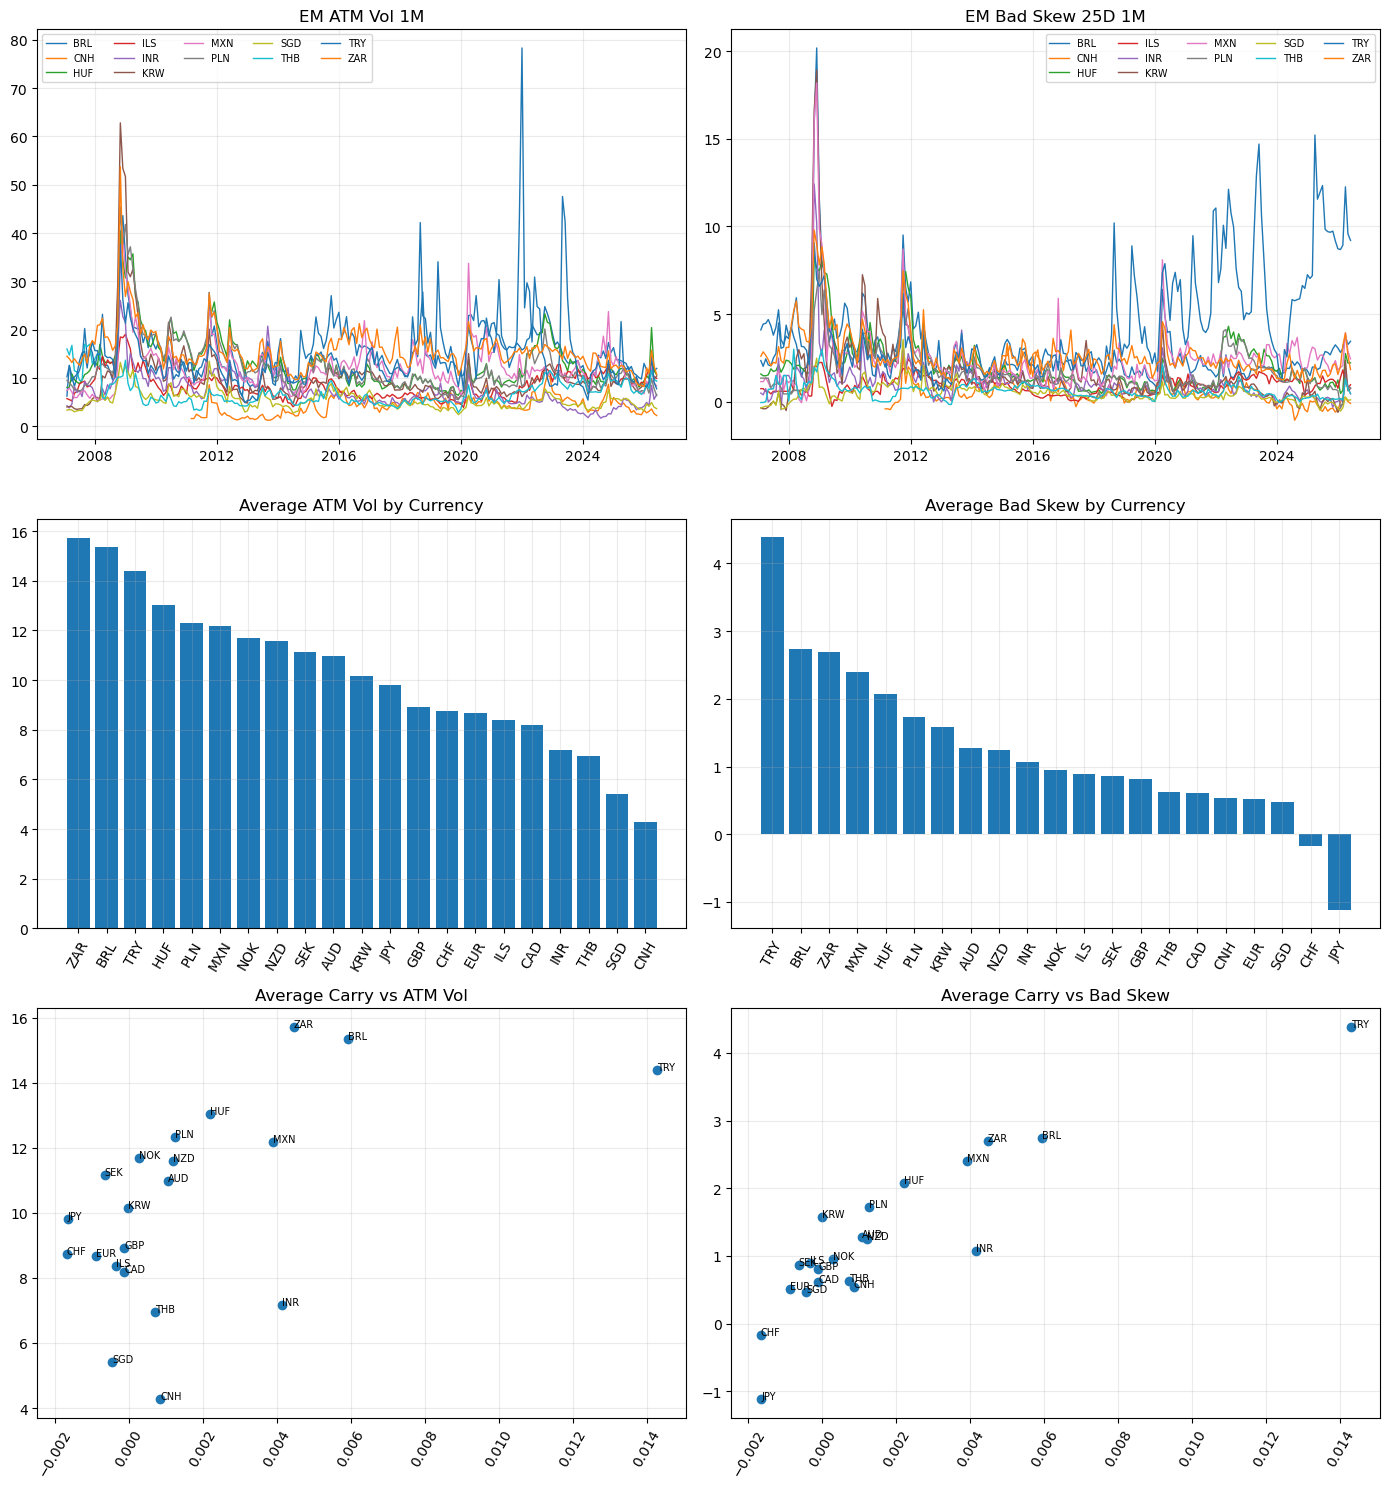

In [9]:
if plt is None or option_carry.empty:
    display(Markdown("Option diagnostic plots skipped."))
else:
    em_plot = option_carry[option_carry["asset_class"].eq("EM")]
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    for ccy, sub in em_plot.groupby("currency"):
        axes[0,0].plot(sub["month_end"], sub["atm_vol_1m"], label=ccy, linewidth=1.0)
        axes[0,1].plot(sub["month_end"], sub["bad_skew25_1m"], label=ccy, linewidth=1.0)
    axes[0,0].set_title("EM ATM Vol 1M")
    axes[0,1].set_title("EM Bad Skew 25D 1M")
    for ax in axes[0]: ax.legend(ncol=5, fontsize=7); ax.grid(alpha=0.25)
    diag_sort = option_diag.sort_values("avg_atm_vol", ascending=False)
    axes[1,0].bar(diag_sort["currency"], diag_sort["avg_atm_vol"]); axes[1,0].set_title("Average ATM Vol by Currency")
    diag_sort2 = option_diag.sort_values("avg_bad_skew25", ascending=False)
    axes[1,1].bar(diag_sort2["currency"], diag_sort2["avg_bad_skew25"]); axes[1,1].set_title("Average Bad Skew by Currency")
    axes[2,0].scatter(option_diag["avg_carry"], option_diag["avg_atm_vol"])
    for _, row in option_diag.iterrows(): axes[2,0].annotate(row["currency"], (row["avg_carry"], row["avg_atm_vol"]), fontsize=7)
    axes[2,0].set_title("Average Carry vs ATM Vol")
    axes[2,1].scatter(option_diag["avg_carry"], option_diag["avg_bad_skew25"])
    for _, row in option_diag.iterrows(): axes[2,1].annotate(row["currency"], (row["avg_carry"], row["avg_bad_skew25"]), fontsize=7)
    axes[2,1].set_title("Average Carry vs Bad Skew")
    for ax in axes[1:].ravel(): ax.tick_params(axis='x', rotation=60); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()


### Option Diagnostics Interpretation

Currencies with high carry and high ATM vol or high bad skew are the most natural candidates for bad-carry filters. TRY, BRL, ZAR, and MXN should be inspected closely because option markets may price their crash risk before realized losses occur.


In [10]:
watch = option_diag[option_diag["currency"].isin(["TRY", "BRL", "ZAR", "MXN", "HUF", "INR"])].sort_values("avg_carry", ascending=False)
display(watch.style.format({"avg_atm_vol":"{:.2f}", "avg_bad_skew25":"{:.2f}", "avg_bf25":"{:.2f}", "avg_carry":"{:.3%}"}) if not watch.empty else watch)


,currency,asset_class,first_option_month,last_option_month,valid_option_months,avg_atm_vol,avg_rr25_foreign,avg_bad_skew25,avg_bf25,avg_carry,missing_option_months
19,TRY,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,14.39,-4.384652,4.38,0.88,1.427%,0
1,BRL,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,15.35,-2.742967,2.74,0.48,0.593%,0
20,ZAR,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,15.72,-2.692200,2.69,0.52,0.447%,0
9,INR,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,7.18,-1.072333,1.07,0.30,0.415%,0
12,MXN,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,233,12.18,-2.397980,2.40,0.43,0.390%,0
7,HUF,EM,2007-01-31 00:00:00,2026-05-31 00:00:00,231,13.04,-2.077073,2.08,0.49,0.220%,2


## Conditional Returns by Option Signal

Before building strategies, the notebook sorts future 1M realized returns by carry, ATM vol, bad skew, and butterflies.


In [11]:
def assign_quantiles_by_month(df, col, q=5, label=None):
    label = label or f"{col}_q"
    out = df.copy()
    out[label] = np.nan
    for dt, sub in out.groupby("month_end"):
        vals = sub[col]
        if vals.notna().sum() < q:
            continue
        try:
            out.loc[sub.index, label] = pd.qcut(vals.rank(method="first"), q, labels=False) + 1
        except Exception:
            pass
    return out

cond = option_carry.copy()
for col, label in [("carry_signal_1m", "carry_q"), ("atm_vol_1m", "vol_q"), ("bad_skew25_1m", "bad_skew_q"), ("bf25_1m", "bf_q")]:
    cond = assign_quantiles_by_month(cond, col, 5, label)

bucket_defs = {
    "high carry + low vol": (cond["carry_q"].eq(5) & cond["vol_q"].eq(1)),
    "high carry + high vol": (cond["carry_q"].eq(5) & cond["vol_q"].eq(5)),
    "high carry + low bad skew": (cond["carry_q"].eq(5) & cond["bad_skew_q"].eq(1)),
    "high carry + high bad skew": (cond["carry_q"].eq(5) & cond["bad_skew_q"].eq(5)),
    "low carry + high bad skew": (cond["carry_q"].eq(1) & cond["bad_skew_q"].eq(5)),
    "high carry + high butterfly": (cond["carry_q"].eq(5) & cond["bf_q"].eq(5)),
}
rows=[]
for bucket, mask in bucket_defs.items():
    for sample_name, sample in [("All", cond), ("G10", cond[cond["asset_class"].eq("G10")]), ("EM", cond[cond["asset_class"].eq("EM")])]:
        sub = sample[mask.reindex(sample.index, fill_value=False)]
        r = sub["realized_1m_forward_excess_return"].dropna()
        rows.append({"sample": sample_name, "bucket": bucket, "observations": len(r), "average_future_return": r.mean() if len(r) else np.nan, "volatility": r.std(ddof=1) if len(r)>1 else np.nan, "sharpe_monthly": r.mean()/r.std(ddof=1) if len(r)>1 and r.std(ddof=1)>0 else np.nan, "hit_rate": (r>0).mean() if len(r) else np.nan, "skewness": r.skew() if len(r)>2 else np.nan, "worst_month": r.min() if len(r) else np.nan})
conditional_table = pd.DataFrame(rows)
display(conditional_table.style.format({"average_future_return":"{:.3%}", "volatility":"{:.3%}", "sharpe_monthly":"{:.2f}", "hit_rate":"{:.1%}", "skewness":"{:.2f}", "worst_month":"{:.2%}"}))


,sample,bucket,observations,average_future_return,volatility,sharpe_monthly,hit_rate,skewness,worst_month
0,All,high carry + low vol,85,0.127%,1.958%,0.06,56.5%,0.05,-4.21%
1,G10,high carry + low vol,0,nan%,nan%,nan,nan%,nan,nan%
2,EM,high carry + low vol,85,0.127%,1.958%,0.06,56.5%,0.05,-4.21%
3,All,high carry + high vol,559,0.373%,4.471%,0.08,58.7%,-1.41,-32.42%
4,G10,high carry + high vol,3,-0.102%,0.697%,-0.15,66.7%,-0.92,-0.86%
5,EM,high carry + high vol,556,0.376%,4.482%,0.08,58.6%,-1.41,-32.42%
6,All,high carry + low bad skew,11,1.378%,2.108%,0.65,81.8%,0.48,-1.70%
7,G10,high carry + low bad skew,0,nan%,nan%,nan,nan%,nan,nan%
8,EM,high carry + low bad skew,11,1.378%,2.108%,0.65,81.8%,0.48,-1.70%
9,All,high carry + high bad skew,639,0.280%,4.378%,0.06,59.8%,-1.57,-32.42%


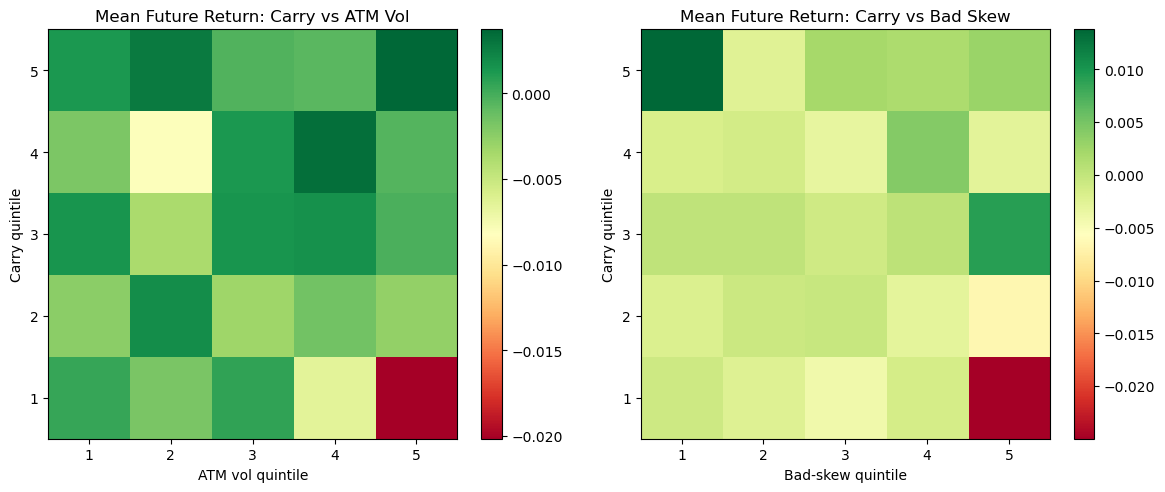

In [12]:
def mean_return_heatmap(df, row_q, col_q):
    return df.pivot_table(index=row_q, columns=col_q, values="realized_1m_forward_excess_return", aggfunc="mean")

heat_carry_vol = mean_return_heatmap(cond, "carry_q", "vol_q")
heat_carry_skew = mean_return_heatmap(cond, "carry_q", "bad_skew_q")

if plt is None:
    display(Markdown("Heatmaps skipped."))
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    im0 = axes[0].imshow(heat_carry_vol.sort_index(ascending=False), cmap="RdYlGn")
    axes[0].set_title("Mean Future Return: Carry vs ATM Vol")
    axes[0].set_xlabel("ATM vol quintile"); axes[0].set_ylabel("Carry quintile")
    axes[0].set_xticks(range(len(heat_carry_vol.columns))); axes[0].set_xticklabels(heat_carry_vol.columns.astype(int))
    axes[0].set_yticks(range(len(heat_carry_vol.index))); axes[0].set_yticklabels(sorted(heat_carry_vol.index.dropna().astype(int), reverse=True))
    fig.colorbar(im0, ax=axes[0], fraction=0.046)
    im1 = axes[1].imshow(heat_carry_skew.sort_index(ascending=False), cmap="RdYlGn")
    axes[1].set_title("Mean Future Return: Carry vs Bad Skew")
    axes[1].set_xlabel("Bad-skew quintile"); axes[1].set_ylabel("Carry quintile")
    axes[1].set_xticks(range(len(heat_carry_skew.columns))); axes[1].set_xticklabels(heat_carry_skew.columns.astype(int))
    axes[1].set_yticks(range(len(heat_carry_skew.index))); axes[1].set_yticklabels(sorted(heat_carry_skew.index.dropna().astype(int), reverse=True))
    fig.colorbar(im1, ax=axes[1], fraction=0.046)
    plt.tight_layout(); plt.show()


### Conditional Return Interpretation

These sorts are exploratory. If high carry performs better when ATM vol or bad skew is low, option signals may help identify safer carry. If high carry with high bad skew has poor downside outcomes, skew is a plausible bad-carry warning signal.


## Exploratory Predictive Regressions

These pooled regressions are exploratory and not a full out-of-sample predictive model.


In [13]:
def ols_with_tstats(df, y_col, x_cols):
    data = df[[y_col] + x_cols].dropna().copy()
    if len(data) <= len(x_cols) + 2:
        return pd.DataFrame()
    y = data[y_col].values.astype(float)
    X = data[x_cols].values.astype(float)
    X = np.column_stack([np.ones(len(X)), X])
    names = ["const"] + x_cols
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = max(len(y) - X.shape[1], 1)
    sigma2 = resid @ resid / dof
    cov = sigma2 * np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    t = beta / se
    return pd.DataFrame({"variable": names, "coefficient": beta, "t_stat": t, "n_obs": len(y)})

reg_data = option_carry.copy()
reg_data["carry_x_bad_skew"] = reg_data["carry_signal_1m"] * reg_data["bad_skew25_1m"]
reg_rows=[]
models = {
    "simple": ["carry_signal_1m", "atm_vol_1m", "bad_skew25_1m"],
    "interaction": ["carry_signal_1m", "atm_vol_1m", "bad_skew25_1m", "carry_x_bad_skew"],
}
for sample_name, sample in [("All", reg_data), ("G10", reg_data[reg_data["asset_class"].eq("G10")]), ("EM", reg_data[reg_data["asset_class"].eq("EM")])]:
    for model_name, xcols in models.items():
        res = ols_with_tstats(sample, "realized_1m_forward_excess_return", xcols)
        if not res.empty:
            res["sample"] = sample_name
            res["model"] = model_name
            reg_rows.append(res)
regression_results = pd.concat(reg_rows, ignore_index=True) if reg_rows else pd.DataFrame()
display(regression_results.style.format({"coefficient":"{:.5f}", "t_stat":"{:.2f}"}) if not regression_results.empty else regression_results)


/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_21361/1031608785.py:10: RuntimeWarning: divide by zero encountered in matmul
  resid = y - X @ beta
/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_21361/1031608785.py:10: RuntimeWarning: overflow encountered in matmul
  resid = y - X @ beta
/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_21361/1031608785.py:10: RuntimeWarning: invalid value encountered in matmul
  resid = y - X @ beta
/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_21361/1031608785.py:12: RuntimeWarning: divide by zero encountered in matmul
  sigma2 = resid @ resid / dof
/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_21361/1031608785.py:12: RuntimeWarning: overflow encountered in matmul
  sigma2 = resid @ resid / dof
/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_21361/1031608785.py:12: RuntimeWarning: invalid value encountered in matmul
  sigma2 = resid @ resid / dof
/var/folders/zs/t66fm21n3rndqc_bp6z2

,variable,coefficient,t_stat,n_obs,sample,model
0,const,-0.00296,-2.74,4842,All,simple
1,carry_signal_1m,0.02728,0.21,4842,All,simple
2,atm_vol_1m,0.00023,1.96,4842,All,simple
3,bad_skew25_1m,0.00031,0.71,4842,All,simple
4,const,-0.00311,-2.87,4842,All,interaction
5,carry_signal_1m,0.32257,1.73,4842,All,interaction
6,atm_vol_1m,0.00022,1.90,4842,All,interaction
7,bad_skew25_1m,0.00035,0.81,4842,All,interaction
8,carry_x_bad_skew,-0.04433,-2.23,4842,All,interaction
9,const,-0.00713,-3.45,2097,G10,simple


## Option-Filtered Carry Strategies

All filtered strategies use the same option-available universe for each strategy family. The baseline in this section is therefore an option-available baseline, not the broader full-universe baseline from prior notebooks.


In [14]:
def max_drawdown_initial(r):
    r = r.dropna().astype(float)
    if r.empty:
        return np.nan
    wealth = pd.concat([pd.Series([1.0], index=["initial"]), (1.0 + r).cumprod()])
    return (wealth / wealth.cummax() - 1.0).min()

def perf_stats(r):
    r = r.dropna().astype(float)
    if r.empty:
        return {"months": 0}
    ann = (1+r).prod() ** (MONTHS_PER_YEAR / len(r)) - 1
    vol = r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR)
    return {"months": len(r), "annualized_return": ann, "annualized_volatility": vol, "sharpe_ratio": ann/vol if vol and pd.notna(vol) else np.nan, "max_drawdown": max_drawdown_initial(r), "skewness": r.skew(), "hit_rate": (r>0).mean(), "best_month": r.max(), "worst_month": r.min(), "final_cumulative_return": (1+r).prod()-1}

def choose_leg_size(n):
    if n < 2: return 0
    if n >= 6: return min(max(math.ceil(0.20*n), 3), n//2)
    return max(1, n//3)

def zscore_by_month(df, col):
    return df.groupby("month_end")[col].transform(lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) and pd.notna(x.std(ddof=0)) else 0.0)

def apply_filter(df, variant):
    out = df.copy()
    out["excluded_by_filter"] = False
    out["score"] = out["carry_signal_1m"]
    if variant == "baseline":
        return out
    for dt, sub in out.groupby("month_end"):
        idx = sub.index
        if len(sub) < 5:
            continue
        vol_cut = sub["atm_vol_1m"].quantile(0.80)
        skew_cut = sub["bad_skew25_1m"].quantile(0.80)
        if variant == "high-vol exclusion":
            out.loc[idx, "excluded_by_filter"] = sub["atm_vol_1m"] >= vol_cut
        elif variant == "bad-skew exclusion":
            out.loc[idx, "excluded_by_filter"] = sub["bad_skew25_1m"] >= skew_cut
        elif variant == "high-vol or bad-skew exclusion":
            out.loc[idx, "excluded_by_filter"] = (sub["atm_vol_1m"] >= vol_cut) | (sub["bad_skew25_1m"] >= skew_cut)
        elif variant.startswith("score"):
            lam = float(variant.split("lambda=")[1].split(",")[0])
            gam = float(variant.split("gamma=")[1])
            zc = (sub["carry_signal_1m"] - sub["carry_signal_1m"].mean()) / (sub["carry_signal_1m"].std(ddof=0) or 1)
            zv = (sub["atm_vol_1m"] - sub["atm_vol_1m"].mean()) / (sub["atm_vol_1m"].std(ddof=0) or 1)
            zs = (sub["bad_skew25_1m"] - sub["bad_skew25_1m"].mean()) / (sub["bad_skew25_1m"].std(ddof=0) or 1)
            out.loc[idx, "score"] = zc - lam*zv - gam*zs
    return out[~out["excluded_by_filter"]].copy()

def build_filtered_strategy(sample_name, df, variant="baseline", scale_target=None, risk_scale=None):
    filtered = apply_filter(df, variant)
    rows=[]
    for dt, sub in filtered.groupby("month_end", sort=True):
        sub = sub.dropna(subset=["score", "realized_1m_forward_excess_return"]).sort_values(["score", "currency"]).copy()
        n = len(sub); k = choose_leg_size(n)
        if k == 0 or n < 2*k:
            continue
        sub["weight"] = 0.0; sub["basket"] = "middle"
        sub.loc[sub.head(k).index, "weight"] = -1.0/k; sub.loc[sub.head(k).index, "basket"] = "short_low_carry"
        sub.loc[sub.tail(k).index, "weight"] = 1.0/k; sub.loc[sub.tail(k).index, "basket"] = "long_high_carry"
        sub["month_end"] = dt; sub["sample"] = sample_name; sub["variant"] = variant
        sub["n_universe"] = n; sub["leg_size"] = k
        rows.append(sub)
    if not rows:
        return pd.DataFrame(), pd.DataFrame()
    weights = pd.concat(rows, ignore_index=True).sort_values(["month_end", "currency"])
    weights["contribution"] = weights["weight"] * weights["realized_1m_forward_excess_return"]
    rets=[]
    for dt, sub in weights.groupby("month_end", sort=True):
        original_n = df[df["month_end"].eq(dt)]["currency"].nunique()
        rets.append({"sample": sample_name, "variant": variant, "month_end": dt, "gross_return": sub["contribution"].sum(), "gross_roll_notional": sub["weight"].abs().sum(), "n_universe": sub["n_universe"].max(), "n_excluded": max(original_n - sub["n_universe"].max(), 0), "avg_atm_vol_portfolio": np.average(sub["atm_vol_1m"], weights=sub["weight"].abs()), "avg_bad_skew_portfolio": np.average(sub["bad_skew25_1m"], weights=sub["weight"].abs()), "long_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("long_high_carry"), "currency"])), "short_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("short_low_carry"), "currency"]))})
    returns = pd.DataFrame(rets).sort_values("month_end")
    if scale_target is not None:
        # De-risking only: use average portfolio ATM vol, approximate vol points as annualized percent.
        option_vol = returns["avg_atm_vol_portfolio"] / 100.0
        leverage = (scale_target / option_vol).clip(upper=1.0).fillna(1.0)
        returns["option_vol_scale"] = leverage
        returns["gross_return"] = returns["gross_return"] * leverage
        returns["gross_roll_notional"] = returns["gross_roll_notional"] * leverage
        weights = weights.merge(returns[["month_end", "option_vol_scale"]], on="month_end", how="left")
        weights["weight"] = weights["weight"] * weights["option_vol_scale"].fillna(1.0)
        weights["contribution"] = weights["weight"] * weights["realized_1m_forward_excess_return"]
    if risk_scale is not None:
        returns = returns.merge(risk_scale[["month_end", "risk_scale"]], on="month_end", how="left")
        returns["risk_scale"] = returns["risk_scale"].fillna(1.0)
        returns["gross_return"] = returns["gross_return"] * returns["risk_scale"]
        returns["gross_roll_notional"] = returns["gross_roll_notional"] * returns["risk_scale"].abs()
        weights = weights.merge(returns[["month_end", "risk_scale"]], on="month_end", how="left")
        weights["weight"] = weights["weight"] * weights["risk_scale"].fillna(1.0)
        weights["contribution"] = weights["weight"] * weights["realized_1m_forward_excess_return"]
    for bps in ROLL_COST_BPS:
        returns[f"net_roll_{bps}bp"] = returns["gross_return"] - returns["gross_roll_notional"] * bps / 10000.0
    returns["wealth_gross"] = (1+returns["gross_return"]).cumprod()
    returns["drawdown_gross"] = returns["wealth_gross"] / returns["wealth_gross"].cummax() - 1
    returns["rolling_12m_return"] = returns["wealth_gross"] / returns["wealth_gross"].shift(12) - 1
    return weights, returns

STRATEGY_VARIANTS = ["baseline", "high-vol exclusion", "bad-skew exclusion", "high-vol or bad-skew exclusion", "score lambda=0.25,gamma=0.25", "score lambda=0.5,gamma=0.5", "score lambda=1.0,gamma=1.0"]
strategy_weights=[]; strategy_returns=[]
for sample_name, df in option_samples.items():
    for variant in STRATEGY_VARIANTS:
        w,r = build_filtered_strategy(sample_name, df, variant=variant)
        if not r.empty:
            strategy_weights.append(w); strategy_returns.append(r)
    for target in [0.08, 0.10]:
        w,r = build_filtered_strategy(sample_name, df, variant=f"de-risk option vol target {int(target*100)}pct", scale_target=target)
        if not r.empty:
            strategy_weights.append(w); strategy_returns.append(r)
option_strategy_weights = pd.concat(strategy_weights, ignore_index=True) if strategy_weights else pd.DataFrame()
option_strategy_returns = pd.concat(strategy_returns, ignore_index=True) if strategy_returns else pd.DataFrame()

display(option_strategy_returns.groupby(["sample", "variant"]).agg(months=("month_end", "count"), avg_n=("n_universe", "mean"), avg_excluded=("n_excluded", "mean"), avg_roll=("gross_roll_notional", "mean")).head(50))


months      avg_n  avg_excluded  avg_roll
sample               variant                                                                   
EM option sample     bad-skew exclusion                  233   8.000000      2.991416  2.000000
                     baseline                            233  10.991416      0.000000  2.000000
                     de-risk option vol target 10pct     233  10.991416      0.000000  1.784745
                     de-risk option vol target 8pct      233  10.991416      0.000000  1.522208
                     high-vol exclusion                  233   7.995708      2.995708  2.000000
                     high-vol or bad-skew exclusion      233   6.931330      4.060086  2.000000
                     score lambda=0.25,gamma=0.25        233  10.991416      0.000000  2.000000
                     score lambda=0.5,gamma=0.5          233  10.991416      0.000000  2.000000
                     score lambda=1.0,gamma=1.0          233  10.991416      0.000000  2.000000
G10 option sample    bad-skew exclusion                  233   6.991416      2.008584  2.000000
                     baseline                            233   9.000000      0.000000  2.000000
                     de-risk option vol target 10pct     233   9.000000      0.000000  1.836266
                     de-risk option vol target 8pct      233   9.000000      0.000000  1.647801
                     high-vol exclusion                  233   6.995708      2.004292  2.000000
                     high-vol or bad-skew exclusion      233   5.957082      3.042918  2.000000
                     score lambda=0.25,gamma=0.25        233   9.000000      0.000000  2.000000
                     score lambda=0.5,gamma=0.5          233   9.000000      0.000000  2.000000
                     score lambda=1.0,gamma=1.0          233   9.000000      0.000000  2.000000
G10+EM option sample bad-skew exclusion                  233  15.982833      4.008584  2.000000
                     baseline                            233  19.991416      0.000000  2.000000
                     de-risk option vol target 10pct     233  19.991416      0.000000  1.757183
                     de-risk option vol target 8pct      233  19.991416      0.000000  1.479765
                     high-vol exclusion                  233  15.987124      4.004292  2.000000
                     high-vol or bad-skew exclusion      233  14.708155      5.283262  2.000000
                     score lambda=0.25,gamma=0.25        233  19.991416      0.000000  2.000000
                     score lambda=0.5,gamma=0.5          233  19.991416      0.000000  2.000000
                     score lambda=1.0,gamma=1.0          233  19.991416      0.000000  2.000000

## Option-Filtered Performance and Roll-Cost Stress Tests

All performance statistics include max drawdown with initial wealth equal to 1.0.


In [15]:
def performance_table(returns):
    rows=[]
    if returns.empty:
        return pd.DataFrame()
    for (sample, variant), sub in returns.groupby(["sample", "variant"]):
        for col in ["gross_return"] + [f"net_roll_{bps}bp" for bps in ROLL_COST_BPS]:
            stats = perf_stats(sub[col])
            rows.append({"sample": sample, "variant": variant, "scenario": "Gross" if col=="gross_return" else col.replace("net_roll_", "Net roll "), **stats, "avg_n_universe": sub["n_universe"].mean(), "avg_n_excluded": sub["n_excluded"].mean(), "avg_gross_roll_notional": sub["gross_roll_notional"].mean()})
    return pd.DataFrame(rows)

option_performance = performance_table(option_strategy_returns)
show = option_performance[(option_performance["scenario"].isin(["Gross", "Net roll 5bp", "Net roll 25bp"])) & (option_performance["sample"].isin(["EM option sample", "G10+EM option sample"]))]
display(show.sort_values(["sample", "variant", "scenario"]).style.format({"annualized_return":"{:.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:.2f}", "max_drawdown":"{:.2%}", "skewness":"{:.2f}", "hit_rate":"{:.2%}", "best_month":"{:.2%}", "worst_month":"{:.2%}", "final_cumulative_return":"{:.2%}", "avg_n_universe":"{:.1f}", "avg_n_excluded":"{:.1f}", "avg_gross_roll_notional":"{:.2f}"}) if not show.empty else show)


,sample,variant,scenario,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,best_month,worst_month,final_cumulative_return,avg_n_universe,avg_n_excluded,avg_gross_roll_notional
0,EM option sample,bad-skew exclusion,Gross,233,2.03%,6.41%,0.32,-26.03%,-0.10,54.94%,5.25%,-5.97%,47.67%,8.0,3.0,2.00
4,EM option sample,bad-skew exclusion,Net roll 25bp,233,-3.92%,6.41%,-0.61,-60.39%,-0.10,44.21%,4.75%,-6.47%,-53.99%,8.0,3.0,2.00
2,EM option sample,bad-skew exclusion,Net roll 5bp,233,0.81%,6.41%,0.13,-30.36%,-0.10,53.22%,5.15%,-6.07%,17.01%,8.0,3.0,2.00
6,EM option sample,baseline,Gross,233,4.31%,9.37%,0.46,-23.59%,-0.95,60.94%,7.30%,-13.06%,126.75%,11.0,0.0,2.00
10,EM option sample,baseline,Net roll 25bp,233,-1.76%,9.37%,-0.19,-57.65%,-0.95,53.65%,6.80%,-13.56%,-29.22%,11.0,0.0,2.00
8,EM option sample,baseline,Net roll 5bp,233,3.07%,9.37%,0.33,-29.30%,-0.95,59.66%,7.20%,-13.16%,79.73%,11.0,0.0,2.00
12,EM option sample,de-risk option vol target 10pct,Gross,233,3.17%,8.08%,0.39,-22.46%,-1.20,60.94%,5.83%,-11.72%,83.15%,11.0,0.0,1.78
16,EM option sample,de-risk option vol target 10pct,Net roll 25bp,233,-2.21%,8.11%,-0.27,-57.96%,-1.20,53.65%,5.43%,-12.17%,-35.26%,11.0,0.0,1.78
14,EM option sample,de-risk option vol target 10pct,Net roll 5bp,233,2.07%,8.09%,0.26,-28.91%,-1.20,59.66%,5.75%,-11.81%,48.81%,11.0,0.0,1.78
18,EM option sample,de-risk option vol target 8pct,Gross,233,2.80%,6.72%,0.42,-19.91%,-1.08,60.94%,4.66%,-9.37%,70.79%,11.0,0.0,1.52


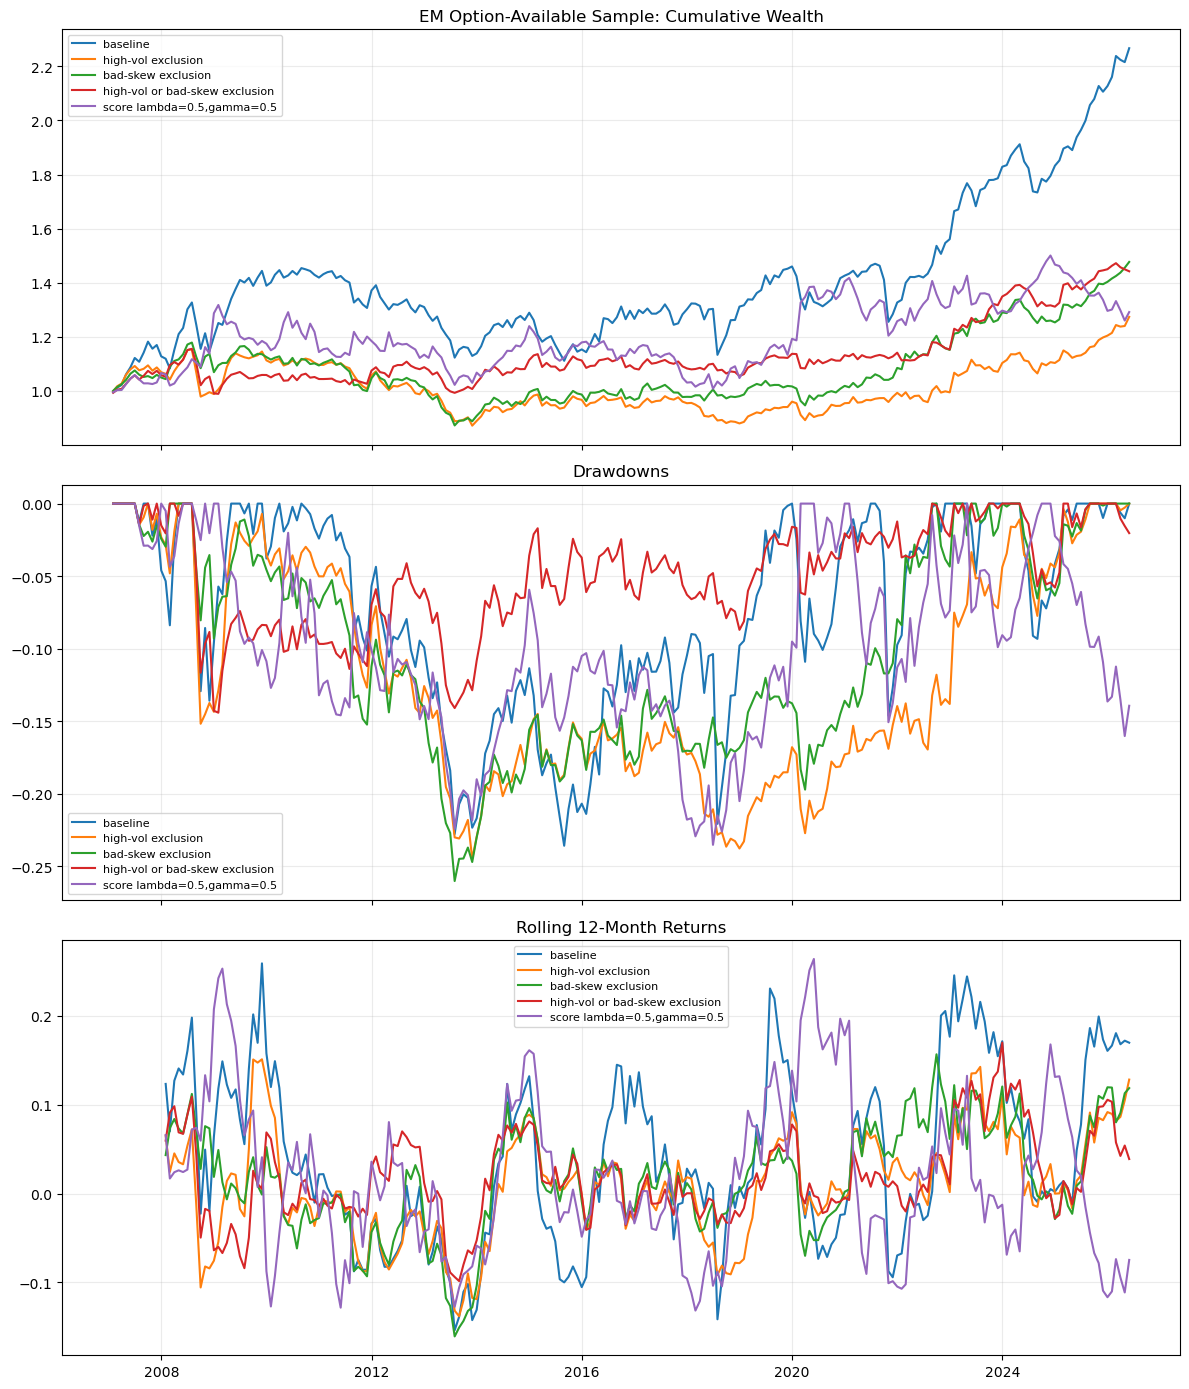

In [16]:
if plt is None or option_strategy_returns.empty:
    display(Markdown("Strategy plots skipped."))
else:
    plot_sample = "EM option sample"
    variants_to_plot = ["baseline", "high-vol exclusion", "bad-skew exclusion", "high-vol or bad-skew exclusion", "score lambda=0.5,gamma=0.5"]
    fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
    for variant in variants_to_plot:
        sub = option_strategy_returns[(option_strategy_returns["sample"].eq(plot_sample)) & (option_strategy_returns["variant"].eq(variant))]
        if sub.empty: continue
        axes[0].plot(sub["month_end"], sub["wealth_gross"], label=variant)
        axes[1].plot(sub["month_end"], sub["drawdown_gross"], label=variant)
        axes[2].plot(sub["month_end"], sub["rolling_12m_return"], label=variant)
    axes[0].set_title("EM Option-Available Sample: Cumulative Wealth")
    axes[1].set_title("Drawdowns")
    axes[2].set_title("Rolling 12-Month Returns")
    for ax in axes: ax.grid(alpha=0.25); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


## Global Risk-Regime Filters

Risk filters use only information available up to month `t`. Rolling percentile thresholds use historical observations through the current month.


In [17]:
def build_monthly_risk(df):
    if df.empty:
        return pd.DataFrame()
    raw = df.copy()
    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw["value"] = pd.to_numeric(raw["value"], errors="coerce")
    px = raw[raw["field"].eq("PX_LAST")].pivot_table(index="date", columns="ticker", values="value", aggfunc="last").sort_index()
    monthly = px.resample("ME").last().reset_index().rename(columns={"date": "month_end"})
    rename = {"VIX Index":"VIX", "MOVE Index":"MOVE", "DXY Curncy":"DXY", "JPMVXYGL Index":"JPMVXYGL", "JPMVXYG7 Index":"JPMVXYG7", "JPMVXYEM Index":"JPMVXYEM", "SPX Index":"SPX", "MXEF Index":"MXEF", "USGG2YR Index":"USGG2YR", "USGG10YR Index":"USGG10YR"}
    monthly = monthly.rename(columns=rename)
    return monthly

risk_monthly = build_monthly_risk(global_risk_raw)
if risk_monthly.empty:
    display(Markdown("Global risk data unavailable; risk-regime filters skipped."))
else:
    risk = risk_monthly.copy()
    for col in ["VIX", "JPMVXYEM"]:
        if col in risk:
            risk[f"{col}_roll80"] = risk[col].rolling(60, min_periods=24).quantile(0.80)
    if "DXY" in risk:
        risk["DXY_3m_mom"] = np.log(risk["DXY"]) - np.log(risk["DXY"].shift(3))
        risk["DXY_mom_roll80"] = risk["DXY_3m_mom"].rolling(60, min_periods=24).quantile(0.80)
    if "SPX" in risk:
        risk["SPX_drawdown_6m"] = risk["SPX"] / risk["SPX"].rolling(6, min_periods=3).max() - 1
    risk["risk_off_vix"] = risk.get("VIX", pd.Series(index=risk.index, dtype=float)) > risk.get("VIX_roll80", np.nan)
    risk["risk_off_jpmvxyem"] = risk.get("JPMVXYEM", pd.Series(index=risk.index, dtype=float)) > risk.get("JPMVXYEM_roll80", np.nan)
    risk["risk_off_dxy"] = risk.get("DXY_3m_mom", pd.Series(index=risk.index, dtype=float)) > risk.get("DXY_mom_roll80", np.nan)
    risk["risk_off_equity"] = risk.get("SPX_drawdown_6m", pd.Series(index=risk.index, dtype=float)) < -0.10
    risk["risk_off_any"] = risk[["risk_off_vix", "risk_off_jpmvxyem", "risk_off_dxy", "risk_off_equity"]].fillna(False).any(axis=1)
    risk_scales = risk[["month_end", "risk_off_any", "VIX", "JPMVXYEM", "DXY_3m_mom", "SPX_drawdown_6m"]].copy()
    display(risk_scales.tail())


ticker,month_end,risk_off_any,VIX,JPMVXYEM,DXY_3m_mom,SPX_drawdown_6m
229,2026-02-28,False,19.86,6.95,-0.018786,-0.008668
230,2026-03-31,True,25.25,8.69,0.016532,-0.059160
231,2026-04-30,False,16.89,7.11,0.010921,0.000000
232,2026-05-31,False,15.32,6.90,0.013574,0.000000
233,2026-06-30,False,16.45,6.68,0.011884,-0.010646


In [18]:
risk_strategy_returns=[]; risk_strategy_weights=[]
if not risk_monthly.empty and 'risk_scales' in globals():
    base_sample = option_samples["G10+EM option sample"]
    base_variants = ["baseline", "high-vol or bad-skew exclusion"]
    for base_variant in base_variants:
        for mode, scale_value in [("risk-off 50pct", 0.5), ("risk-off zero", 0.0)]:
            rs = risk_scales.copy()
            rs["risk_scale"] = np.where(rs["risk_off_any"], scale_value, 1.0)
            w, r = build_filtered_strategy("G10+EM option sample", base_sample, variant=f"{base_variant} + global {mode}", risk_scale=rs[["month_end", "risk_scale"]])
            if not r.empty:
                risk_strategy_weights.append(w); risk_strategy_returns.append(r)
if risk_strategy_returns:
    risk_strategy_weights = pd.concat(risk_strategy_weights, ignore_index=True)
    risk_strategy_returns = pd.concat(risk_strategy_returns, ignore_index=True)
    risk_perf = performance_table(risk_strategy_returns)
    display(risk_perf[risk_perf["scenario"].isin(["Gross", "Net roll 5bp", "Net roll 25bp"])].style.format({"annualized_return":"{:.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:.2f}", "max_drawdown":"{:.2%}", "skewness":"{:.2f}", "final_cumulative_return":"{:.2%}"}))
else:
    risk_strategy_weights = pd.DataFrame(); risk_strategy_returns = pd.DataFrame(); risk_perf = pd.DataFrame()
    display(Markdown("No global risk-regime strategy variants were created."))


,sample,variant,scenario,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,best_month,worst_month,final_cumulative_return,avg_n_universe,avg_n_excluded,avg_gross_roll_notional
0,G10+EM option sample,baseline + global risk-off 50pct,Gross,233,4.17%,7.33%,0.57,-12.57%,-0.70,0.618026,0.060861,-0.097277,120.93%,19.991416,0.000000,1.643777
2,G10+EM option sample,baseline + global risk-off 50pct,Net roll 5bp,233,3.15%,7.33%,0.43,-15.34%,-0.72,0.592275,0.059861,-0.098277,82.53%,19.991416,0.000000,1.643777
4,G10+EM option sample,baseline + global risk-off 50pct,Net roll 25bp,233,-0.84%,7.32%,-0.11,-41.78%,-0.77,0.515021,0.055861,-0.102277,-15.10%,19.991416,0.000000,1.643777
6,G10+EM option sample,baseline + global risk-off zero,Gross,233,3.28%,6.67%,0.49,-13.68%,-0.61,0.394850,0.060861,-0.097277,87.05%,19.991416,0.000000,1.287554
8,G10+EM option sample,baseline + global risk-off zero,Net roll 5bp,233,2.49%,6.65%,0.37,-15.23%,-0.67,0.377682,0.059861,-0.098277,61.08%,19.991416,0.000000,1.287554
10,G10+EM option sample,baseline + global risk-off zero,Net roll 25bp,233,-0.63%,6.63%,-0.10,-36.99%,-0.90,0.330472,0.055861,-0.102277,-11.55%,19.991416,0.000000,1.287554
12,G10+EM option sample,high-vol or bad-skew exclusion + global risk-off 50pct,Gross,233,4.17%,7.33%,0.57,-12.57%,-0.70,0.618026,0.060861,-0.097277,120.93%,19.991416,0.000000,1.643777
14,G10+EM option sample,high-vol or bad-skew exclusion + global risk-off 50pct,Net roll 5bp,233,3.15%,7.33%,0.43,-15.34%,-0.72,0.592275,0.059861,-0.098277,82.53%,19.991416,0.000000,1.643777
16,G10+EM option sample,high-vol or bad-skew exclusion + global risk-off 50pct,Net roll 25bp,233,-0.84%,7.32%,-0.11,-41.78%,-0.77,0.515021,0.055861,-0.102277,-15.10%,19.991416,0.000000,1.643777
18,G10+EM option sample,high-vol or bad-skew exclusion + global risk-off zero,Gross,233,3.28%,6.67%,0.49,-13.68%,-0.61,0.394850,0.060861,-0.097277,87.05%,19.991416,0.000000,1.287554


## Crisis-Period Analysis and Attribution

The crisis tables compare baseline and major option-filtered variants during known stress windows.


In [19]:
CRISIS_WINDOWS = [
    {"period": "2008 global financial crisis", "start": "2008-07-31", "end": "2009-03-31"},
    {"period": "2013 taper tantrum", "start": "2013-05-31", "end": "2013-09-30"},
    {"period": "2015 EM / China stress", "start": "2015-06-30", "end": "2016-02-29"},
    {"period": "2020 Covid shock", "start": "2020-02-29", "end": "2020-04-30"},
    {"period": "2022 dollar / rates shock", "start": "2022-01-31", "end": "2022-10-31"},
]

major_variants = ["baseline", "high-vol exclusion", "bad-skew exclusion", "high-vol or bad-skew exclusion", "score lambda=0.5,gamma=0.5"]
major_returns = option_strategy_returns[(option_strategy_returns["sample"].isin(["EM option sample", "G10+EM option sample"])) & (option_strategy_returns["variant"].isin(major_variants))].copy()
major_weights = option_strategy_weights[(option_strategy_weights["sample"].isin(["EM option sample", "G10+EM option sample"])) & (option_strategy_weights["variant"].isin(major_variants))].copy()

crisis_rows=[]; crisis_contrib_rows=[]
for (sample, variant), sub0 in major_returns.groupby(["sample", "variant"]):
    w0 = major_weights[(major_weights["sample"].eq(sample)) & (major_weights["variant"].eq(variant))]
    for win in CRISIS_WINDOWS:
        pre_start = pd.Timestamp(win["start"]) - pd.DateOffset(months=3)
        pre_end = pd.Timestamp(win["start"]) - pd.DateOffset(months=1)
        sub = sub0[(sub0["month_end"] >= pd.Timestamp(win["start"])) & (sub0["month_end"] <= pd.Timestamp(win["end"]))]
        r = sub["gross_return"].dropna()
        if r.empty: continue
        worst = sub.loc[sub["gross_return"].idxmin()]
        w_period = w0[(w0["month_end"] >= pd.Timestamp(win["start"])) & (w0["month_end"] <= pd.Timestamp(win["end"]))]
        contrib = w_period.groupby("currency")["contribution"].sum().sort_values()
        excluded = option_samples[sample]
        before = excluded[(excluded["month_end"] >= pre_start) & (excluded["month_end"] <= pre_end)]
        during = excluded[(excluded["month_end"] >= pd.Timestamp(win["start"])) & (excluded["month_end"] <= pd.Timestamp(win["end"]))]
        crisis_rows.append({"sample": sample, "variant": variant, "period": win["period"], "period_return": (1+r).prod()-1, "max_drawdown": max_drawdown_initial(r), "worst_month": worst["month_end"], "worst_month_return": worst["gross_return"], "avg_atm_vol_before": before["atm_vol_1m"].mean(), "avg_atm_vol_during": during["atm_vol_1m"].mean(), "avg_bad_skew_before": before["bad_skew25_1m"].mean(), "avg_bad_skew_during": during["bad_skew25_1m"].mean(), "long_basket_worst": worst["long_basket"], "short_basket_worst": worst["short_basket"]})
        for ccy, val in contrib.items():
            crisis_contrib_rows.append({"sample": sample, "variant": variant, "period": win["period"], "currency": ccy, "contribution": val})
crisis_table = pd.DataFrame(crisis_rows)
crisis_attribution = pd.DataFrame(crisis_contrib_rows)
display(crisis_table.style.format({"period_return":"{:.2%}", "max_drawdown":"{:.2%}", "worst_month_return":"{:.2%}", "avg_atm_vol_before":"{:.2f}", "avg_atm_vol_during":"{:.2f}", "avg_bad_skew_before":"{:.2f}", "avg_bad_skew_during":"{:.2f}"}) if not crisis_table.empty else crisis_table)


,sample,variant,period,period_return,max_drawdown,worst_month,worst_month_return,avg_atm_vol_before,avg_atm_vol_during,avg_bad_skew_before,avg_bad_skew_during,long_basket_worst,short_basket_worst
0,EM option sample,bad-skew exclusion,2008 global financial crisis,-5.80%,-9.30%,2008-12-31 00:00:00,-5.97%,10.74,22.21,1.65,5.00,"HUF, TRY, ZAR","ILS, SGD, THB"
1,EM option sample,bad-skew exclusion,2013 taper tantrum,-5.18%,-7.13%,2013-07-31 00:00:00,-4.28%,8.26,11.67,1.15,2.04,"BRL, INR, ZAR","ILS, PLN, SGD"
2,EM option sample,bad-skew exclusion,2015 EM / China stress,2.81%,-3.73%,2016-01-31 00:00:00,-2.43%,11.77,11.46,1.55,1.43,"BRL, INR, KRW","HUF, ILS, PLN"
3,EM option sample,bad-skew exclusion,2020 Covid shock,-2.56%,-6.17%,2020-02-29 00:00:00,-4.54%,6.72,12.77,0.81,2.83,"BRL, INR, THB","HUF, ILS, KRW"
4,EM option sample,bad-skew exclusion,2022 dollar / rates shock,7.73%,-2.92%,2022-10-31 00:00:00,-2.92%,12.75,12.77,1.79,2.39,"BRL, INR, MXN","ILS, SGD, THB"
5,EM option sample,baseline,2008 global financial crisis,-0.68%,-13.59%,2008-09-30 00:00:00,-7.08%,10.74,22.21,1.65,5.00,"BRL, TRY, ZAR","KRW, PLN, SGD"
6,EM option sample,baseline,2013 taper tantrum,-5.71%,-8.94%,2013-07-31 00:00:00,-5.37%,8.26,11.67,1.15,2.04,"BRL, INR, TRY","ILS, KRW, SGD"
7,EM option sample,baseline,2015 EM / China stress,-2.48%,-7.60%,2015-06-30 00:00:00,-2.74%,11.77,11.46,1.55,1.43,"BRL, TRY, ZAR","ILS, KRW, SGD"
8,EM option sample,baseline,2020 Covid shock,-4.18%,-8.65%,2020-02-29 00:00:00,-5.77%,6.72,12.77,0.81,2.83,"INR, MXN, TRY","HUF, ILS, KRW"
9,EM option sample,baseline,2022 dollar / rates shock,13.56%,-1.93%,2022-10-31 00:00:00,-1.93%,12.75,12.77,1.79,2.39,"BRL, HUF, TRY","ILS, SGD, THB"


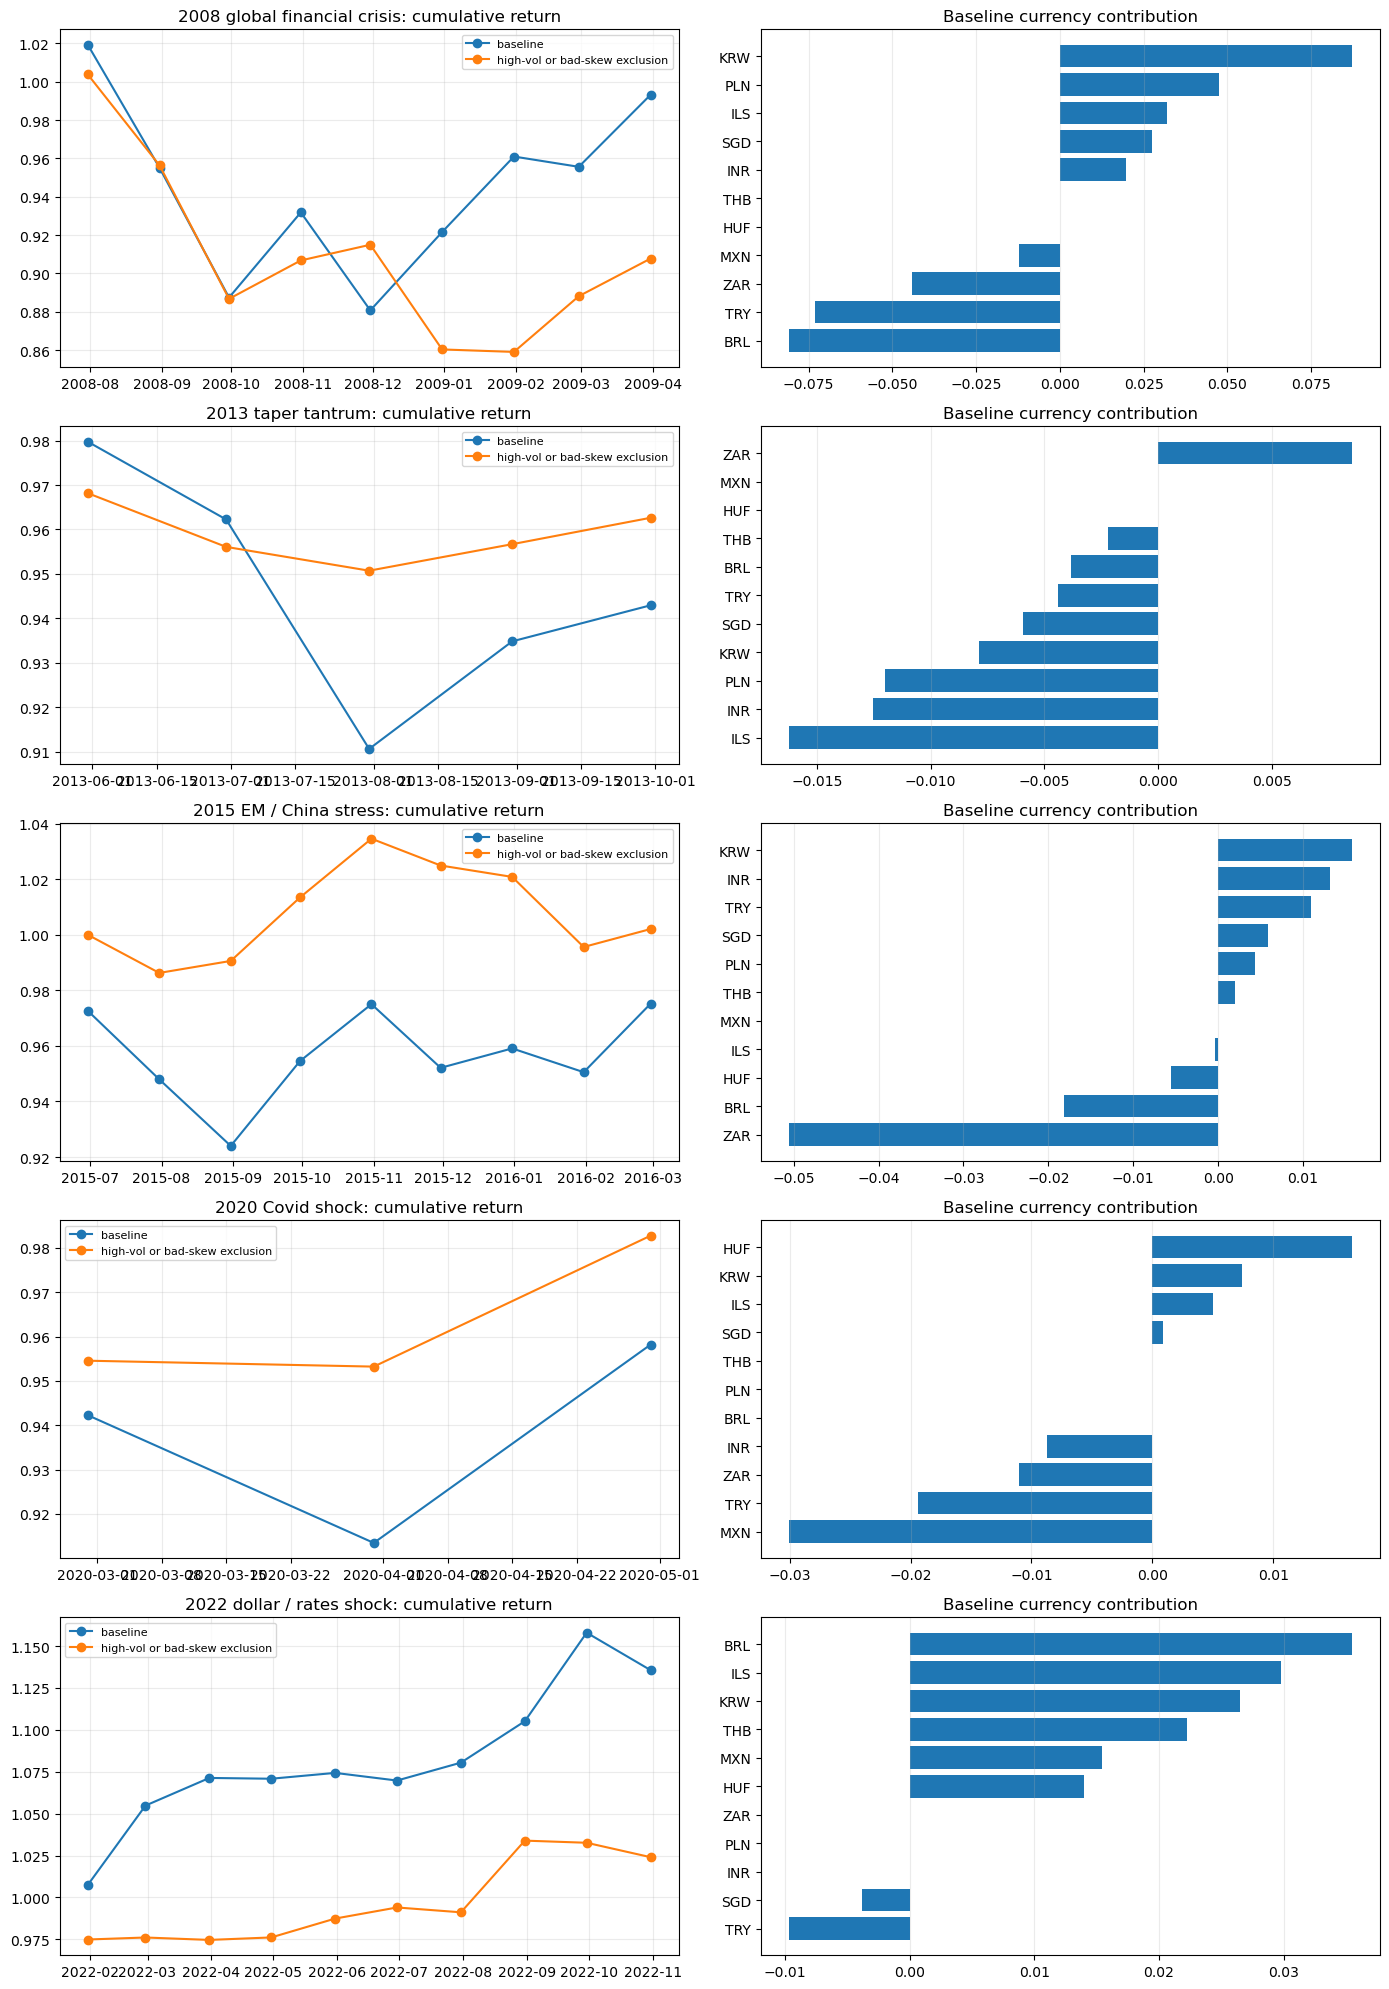

In [20]:
if plt is None or crisis_table.empty:
    display(Markdown("Crisis plots skipped."))
else:
    plot_sample = "EM option sample"
    plot_variants = ["baseline", "high-vol or bad-skew exclusion"]
    fig, axes = plt.subplots(len(CRISIS_WINDOWS), 2, figsize=(14, 4 * len(CRISIS_WINDOWS)))
    for i, win in enumerate(CRISIS_WINDOWS):
        for variant in plot_variants:
            sub = major_returns[(major_returns["sample"].eq(plot_sample)) & (major_returns["variant"].eq(variant)) & (major_returns["month_end"] >= pd.Timestamp(win["start"])) & (major_returns["month_end"] <= pd.Timestamp(win["end"]))]
            if not sub.empty:
                axes[i,0].plot(sub["month_end"], (1+sub["gross_return"]).cumprod(), marker="o", label=variant)
        axes[i,0].set_title(f"{win['period']}: cumulative return")
        axes[i,0].grid(alpha=0.25); axes[i,0].legend(fontsize=8)
        ca = crisis_attribution[(crisis_attribution["sample"].eq(plot_sample)) & (crisis_attribution["variant"].eq("baseline")) & (crisis_attribution["period"].eq(win["period"]))].sort_values("contribution")
        axes[i,1].barh(ca["currency"], ca["contribution"])
        axes[i,1].set_title("Baseline currency contribution")
        axes[i,1].grid(axis="x", alpha=0.25)
    plt.tight_layout(); plt.show()


## Portfolio Attribution After Filters

The contribution tables compare baseline carry with the most relevant option-filtered variants. This helps identify whether filters reduced TRY/BRL/ZAR losses or simply removed profitable carry.


In [21]:
def contribution_summary(weights):
    if weights.empty: return pd.DataFrame()
    rows=[]
    for (sample, variant, ccy), sub in weights.groupby(["sample", "variant", "currency"]):
        rows.append({"sample": sample, "variant": variant, "currency": ccy, "total_contribution": sub["contribution"].sum(), "worst10_contribution": np.nan, "long_side_contribution": sub.loc[sub["basket"].eq("long_high_carry"), "contribution"].sum(), "short_side_contribution": sub.loc[sub["basket"].eq("short_low_carry"), "contribution"].sum()})
    out = pd.DataFrame(rows)
    # Worst 10 month contribution by sample/variant.
    for (sample, variant), subret in option_strategy_returns.groupby(["sample", "variant"]):
        worst_months = set(subret.sort_values("gross_return").head(10)["month_end"])
        mask = (weights["sample"].eq(sample)) & (weights["variant"].eq(variant)) & (weights["month_end"].isin(worst_months))
        wc = weights[mask].groupby("currency")["contribution"].sum()
        for ccy, val in wc.items():
            out.loc[(out["sample"].eq(sample)) & (out["variant"].eq(variant)) & (out["currency"].eq(ccy)), "worst10_contribution"] = val
    out["worst10_contribution"] = out["worst10_contribution"].fillna(0.0)
    return out

filter_contrib = contribution_summary(option_strategy_weights)
compare_contrib = filter_contrib[(filter_contrib["sample"].eq("EM option sample")) & (filter_contrib["variant"].isin(["baseline", "high-vol or bad-skew exclusion", "score lambda=0.5,gamma=0.5"]))]
display(compare_contrib.sort_values(["variant", "total_contribution"], ascending=[True, False]).style.format({"total_contribution":"{:.2%}", "worst10_contribution":"{:.2%}", "long_side_contribution":"{:.2%}", "short_side_contribution":"{:.2%}"}) if not compare_contrib.empty else compare_contrib)


,sample,variant,currency,total_contribution,worst10_contribution,long_side_contribution,short_side_contribution
12,EM option sample,baseline,HUF,28.44%,4.18%,14.33%,14.10%
11,EM option sample,baseline,BRL,24.05%,-18.31%,24.05%,0.00%
15,EM option sample,baseline,KRW,23.59%,3.20%,0.00%,23.59%
14,EM option sample,baseline,INR,15.50%,-2.45%,17.32%,-1.82%
16,EM option sample,baseline,MXN,7.30%,-9.67%,7.30%,0.00%
19,EM option sample,baseline,THB,6.13%,-1.64%,3.55%,2.59%
17,EM option sample,baseline,PLN,4.04%,4.75%,1.11%,2.92%
18,EM option sample,baseline,SGD,-2.56%,3.21%,0.00%,-2.56%
21,EM option sample,baseline,ZAR,-4.92%,-16.57%,-4.92%,0.00%
13,EM option sample,baseline,ILS,-5.08%,-1.96%,0.00%,-5.08%


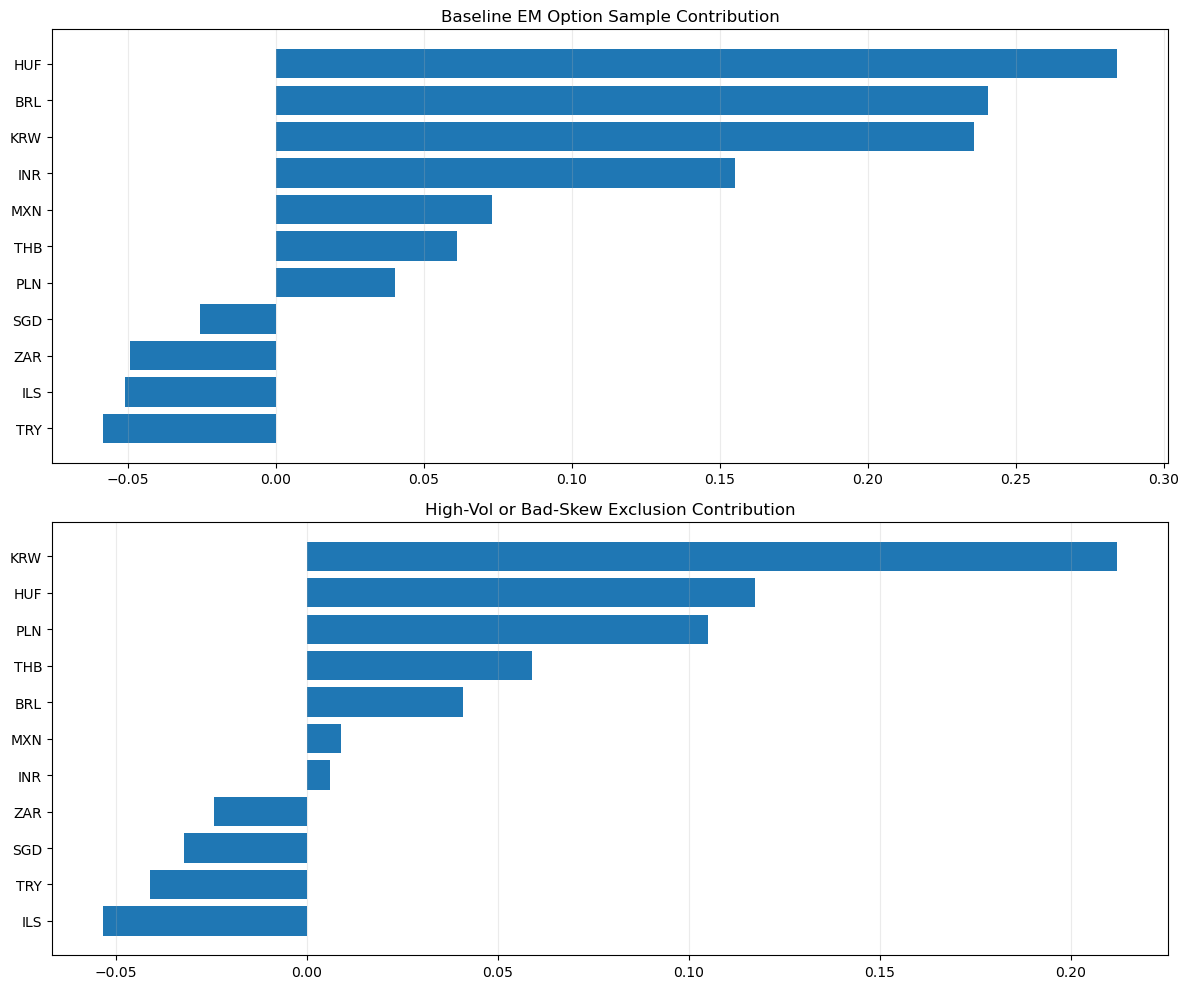

In [22]:
if plt is None or compare_contrib.empty:
    display(Markdown("Filtered attribution plots skipped."))
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    base = compare_contrib[compare_contrib["variant"].eq("baseline")].sort_values("total_contribution")
    filt = compare_contrib[compare_contrib["variant"].eq("high-vol or bad-skew exclusion")].sort_values("total_contribution")
    axes[0].barh(base["currency"], base["total_contribution"]); axes[0].set_title("Baseline EM Option Sample Contribution")
    axes[1].barh(filt["currency"], filt["total_contribution"]); axes[1].set_title("High-Vol or Bad-Skew Exclusion Contribution")
    for ax in axes: ax.grid(axis="x", alpha=0.25)
    plt.tight_layout(); plt.show()


## Overfitting and Interpretation Caveats

Option filters are exploratory. Parameter choices should not be selected only because they maximize Sharpe. Ex-post exclusion tests from notebook 05 are robustness checks, not implementable trading rules. Option-implied signals are more realistic because they are available ex ante, but this notebook still evaluates many variants on the same sample.

A later notebook should do proper out-of-sample validation or walk-forward tuning before treating any filter as a trading rule.


## Save Outputs

The notebook saves the option signal panel, option-filtered strategy returns, option-filter performance table, and crisis attribution table.


In [23]:
all_returns = pd.concat([option_strategy_returns, risk_strategy_returns], ignore_index=True, sort=False) if not risk_strategy_returns.empty else option_strategy_returns.copy()
all_perf = pd.concat([option_performance, risk_perf], ignore_index=True, sort=False) if not risk_perf.empty else option_performance.copy()

option_panel.to_parquet(OPTION_PANEL_OUT, index=False)
all_returns.to_parquet(FILTERED_RETURNS_OUT, index=False)
all_perf.to_parquet(FILTER_PERF_OUT, index=False)
crisis_attribution.to_parquet(CRISIS_ATTRIB_OUT, index=False)

save_table = pd.DataFrame([
    {"file": OPTION_PANEL_OUT.relative_to(ROOT), "rows": len(option_panel)},
    {"file": FILTERED_RETURNS_OUT.relative_to(ROOT), "rows": len(all_returns)},
    {"file": FILTER_PERF_OUT.relative_to(ROOT), "rows": len(all_perf)},
    {"file": CRISIS_ATTRIB_OUT.relative_to(ROOT), "rows": len(crisis_attribution)},
])
display(save_table)


,file,rows
0,theo/data/processed/fx_option_signal_panel.par...,4865
1,theo/data/processed/option_filtered_carry_retu...,7223
2,theo/data/processed/option_filter_performance....,186
3,theo/data/processed/option_filter_crisis_attri...,727


## Final Interpretation

This final section answers whether option-implied signals and global risk filters help identify bad carry ex ante.


In [24]:
def pct(x): return "n/a" if pd.isna(x) else f"{x:.2%}"
try:
    em_base = all_perf[(all_perf["sample"].eq("EM option sample")) & (all_perf["variant"].eq("baseline")) & (all_perf["scenario"].eq("Gross"))].iloc[0]
    em_filter = all_perf[(all_perf["sample"].eq("EM option sample")) & (all_perf["variant"].eq("high-vol or bad-skew exclusion")) & (all_perf["scenario"].eq("Gross"))].iloc[0]
    em_score = all_perf[(all_perf["sample"].eq("EM option sample")) & (all_perf["variant"].eq("score lambda=0.5,gamma=0.5")) & (all_perf["scenario"].eq("Gross"))].iloc[0]
    g10_base = all_perf[(all_perf["sample"].eq("G10 option sample")) & (all_perf["variant"].eq("baseline")) & (all_perf["scenario"].eq("Gross"))].iloc[0]
    risk_best = risk_perf[(risk_perf["scenario"].eq("Gross"))].sort_values("max_drawdown", ascending=False).head(1) if not risk_perf.empty else pd.DataFrame()
    notes = f"""
### Final Answers

- **Do option-implied volatility and skew help identify bad carry?** In the EM option-available sample, baseline Sharpe is {em_base['sharpe_ratio']:.2f}; the high-vol-or-bad-skew exclusion Sharpe is {em_filter['sharpe_ratio']:.2f}; the score-adjusted variant Sharpe is {em_score['sharpe_ratio']:.2f}. This indicates whether option signals add value beyond carry ranking alone.
- **Are high-carry currencies with high ATM vol or bad skew more dangerous?** The conditional return tables compare high-carry/low-vol and high-carry/high-skew buckets. Bad outcomes in the high-carry/high-bad-skew bucket support the bad-carry warning interpretation.
- **Can filters reduce TRY/BRL/ZAR-style losses?** The filtered contribution tables show whether worst-10-month contributions from TRY, BRL, and ZAR are reduced, and whether profitable carry is also removed.
- **Do filters improve Sharpe, drawdown, skewness, or net performance after roll costs?** Compare gross and roll-cost rows in the performance table. A useful filter should improve drawdown or skew without losing too much net return after 10bp to 25bp roll costs.
- **Are filters more useful for EM than G10?** G10 option-sample baseline Sharpe is {g10_base['sharpe_ratio']:.2f}; EM is usually where option-implied crash-risk signals should matter more because carry and crash risk are more dispersed.
- **Are global risk filters complementary?** {'Global risk variants were created and can be compared in the risk-filter performance table.' if not risk_perf.empty else 'Global risk variants were not available because risk data or strategy samples were insufficient.'}
- **Next step:** Any improvement here should be validated in a later out-of-sample or walk-forward notebook before being treated as a production trading rule.
"""
    display(Markdown(notes))
except Exception as exc:
    display(Markdown(f"Final interpretation could not be generated automatically: `{repr(exc)}`"))



### Final Answers

- **Do option-implied volatility and skew help identify bad carry?** In the EM option-available sample, baseline Sharpe is 0.46; the high-vol-or-bad-skew exclusion Sharpe is 0.33; the score-adjusted variant Sharpe is 0.14. This indicates whether option signals add value beyond carry ranking alone.
- **Are high-carry currencies with high ATM vol or bad skew more dangerous?** The conditional return tables compare high-carry/low-vol and high-carry/high-skew buckets. Bad outcomes in the high-carry/high-bad-skew bucket support the bad-carry warning interpretation.
- **Can filters reduce TRY/BRL/ZAR-style losses?** The filtered contribution tables show whether worst-10-month contributions from TRY, BRL, and ZAR are reduced, and whether profitable carry is also removed.
- **Do filters improve Sharpe, drawdown, skewness, or net performance after roll costs?** Compare gross and roll-cost rows in the performance table. A useful filter should improve drawdown or skew without losing too much net return after 10bp to 25bp roll costs.
- **Are filters more useful for EM than G10?** G10 option-sample baseline Sharpe is 0.21; EM is usually where option-implied crash-risk signals should matter more because carry and crash risk are more dispersed.
- **Are global risk filters complementary?** Global risk variants were created and can be compared in the risk-filter performance table.
- **Next step:** Any improvement here should be validated in a later out-of-sample or walk-forward notebook before being treated as a production trading rule.


## Scope Check

This notebook focuses on option-implied signals, risk filters, and ex-ante bad-carry detection. It does not add machine learning.
